<a href="https://colab.research.google.com/github/gauravjha201/Brain_Tumor_Adversarial_Robustness/blob/main/Stage_C_BIM_attack.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Stage_C_BIM_attack**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix,classification_report


In [ ]:
DATASET_PATH="/content/drive/MyDrive/Br35H"

val_dataset=tf.keras.preprocessing.image_dataset_from_directory(
    DATASET_PATH,
    validation_split=0.2,
    subset='validation',
    seed=123,
    image_size=(224,224),
    batch_size=32
)

val_dataset=val_dataset.map(lambda x,y:(x/255,y))

Found 3023 files belonging to 2 classes.
Using 604 files for validation.


In [ ]:
model=tf.keras.models.load_model("/content/drive/MyDrive/baseline_model.h5")
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,083 (9.24 MB)

 Trainable params: 164,097 (641.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

 Optimizer params: 2 (12.00 B)

In [ ]:
clean_loss,clean_acc=model.evaluate(val_dataset)
print(f"Clean Accuracy: {clean_acc*100:.2f}%")
print(f"Clean Loss: {clean_loss:.4f}")

19/19 ━━━━━━━━━━━━━━━━━━━━ 89s 3s/step - accuracy: 0.9834 - loss: 0.0651
Clean Accuracy: 98.34%
Clean Loss: 0.0651


In [ ]:
def bim_attack(model,images,labels,epsilon,alpha,iterations):
  adv_images=images

  for _ in range(iterations):
    with tf.GradientTape() as tape:
        tape.watch(adv_images)
        predictions=model(adv_images)
        loss=tf.keras.losses.sparse_categorical_crossentropy(labels,predictions)

    gradient=tape.gradient(loss,adv_images)
    adv_images=adv_images+alpha*tf.sign(gradient)

    adv_images=tf.clip_by_value(adv_images,images-epsilon,images+epsilon)
    adv_images=tf.clip_by_value(adv_images,0,1)

  return adv_images




In [ ]:
epsilon=0.1
alpha=0.005
iterations=10

bim_acc=[]
bim_loss=[]

for images,labels in val_dataset:
  adv_images=bim_attack(model,images,labels,epsilon,alpha,iterations)
  loss,acc=model.evaluate(adv_images,labels)

  bim_acc.append(acc)
  bim_loss.append(loss)


print(f"BIM Accuracy: {np.mean(bim_acc)*100:.2f}%")
print(f"BIM Loss: {np.mean(bim_loss):.4f}")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step - accuracy: 0.5000 - loss: nan
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step - accuracy: 0.5312 - loss: nan
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step - accuracy: 0.4062 - loss: nan
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 160ms/step - accuracy: 0.4375 - loss: nan
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step - accuracy: 0.3438 - loss: nan
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step - accuracy: 0.5312 - loss: nan
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - accuracy: 0.5000 - loss: nan
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - accuracy: 0.3750 - loss: nan
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - accuracy: 0.4688 - loss: nan
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - accuracy: 0.5625 - loss: nan
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - accuracy: 0.4375 - loss: nan
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step - accuracy: 0.5938 - loss: nan
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - accuracy: 0.3750 - loss: nan
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - accuracy: 0.5625 - loss: nan
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms

In [ ]:
print("\n===== BIM COMPARISON =====")
print("Condition\tAccuracy\tLoss")

print(f"Clean\t\t{clean_acc*100:.2f}%\t{clean_loss:.4f}")
print(f"BIM\t\t{np.mean(bim_acc)*100:.2f}%\t{np.mean(bim_loss):.4f}")


===== BIM COMPARISON =====
Condition	Accuracy	Loss
Clean		98.34%	0.0651
BIM		48.54%	nan


In [ ]:
y_true=[]
y_pred_clean=[]
y_pred_bim=[]

for images,labels in val_dataset:
  adv_images=bim_attack(model,images,labels,epsilon,alpha,iterations)

  preds_clean=model.predict(images)
  preds_clean=(preds_clean>0.5).astype(int)

  preds_bim=model.predict(adv_images)
  preds_bim=(preds_bim>0.5).astype(int)

  y_true.extend(labels.numpy())
  y_pred_clean.extend(preds_clean)
  y_pred_bim.extend(preds_bim)



1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━

In [ ]:
print("=== CLEAN DATA ===")
print(confusion_matrix(y_true, y_pred_clean))

print("\n=== BIM DATA ===")
print(confusion_matrix(y_true, y_pred_bim))

=== CLEAN DATA ===
[[294   4]
 [  6 300]]

=== BIM DATA ===
[[294   4]
 [306   0]]


In [ ]:
print("=== CLEAN REPORT ===")
print(classification_report(y_true, y_pred_clean))

print("\n=== BIM REPORT ===")
print(classification_report(y_true, y_pred_bim))

=== CLEAN REPORT ===
              precision    recall  f1-score   support

           0       0.98      0.99      0.98       298
           1       0.99      0.98      0.98       306

    accuracy                           0.98       604
   macro avg       0.98      0.98      0.98       604
weighted avg       0.98      0.98      0.98       604


=== BIM REPORT ===
              precision    recall  f1-score   support

           0       0.49      0.99      0.65       298
           1       0.00      0.00      0.00       306

    accuracy                           0.49       604
   macro avg       0.24      0.49      0.33       604
weighted avg       0.24      0.49      0.32       604



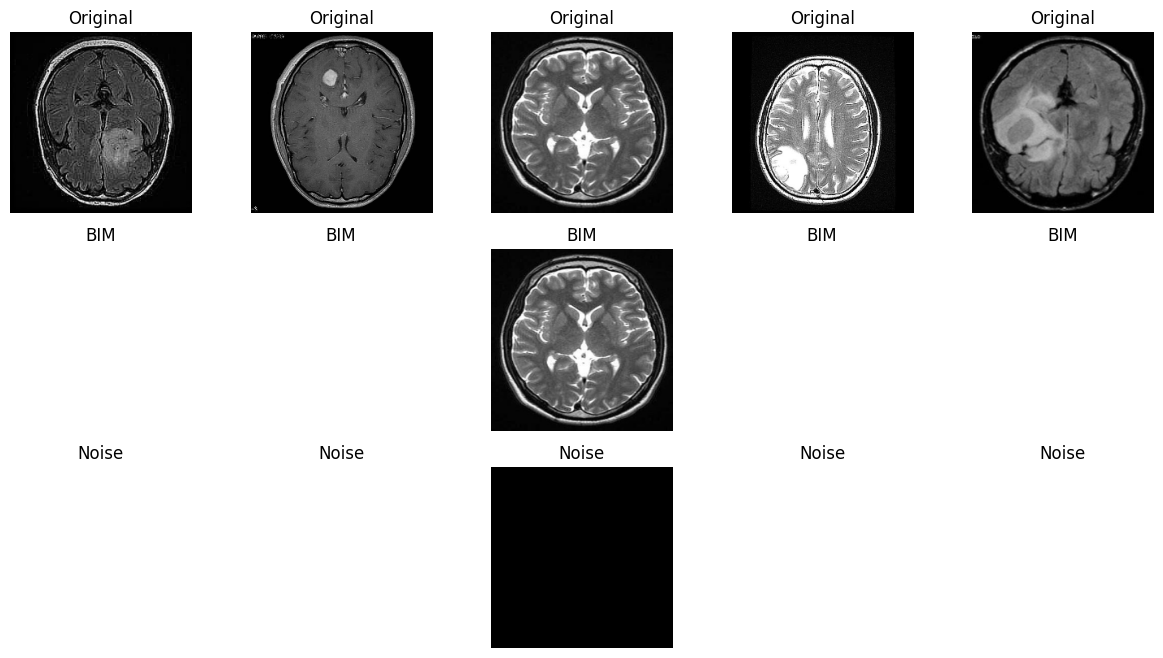

In [ ]:
for images, labels in val_dataset.take(1):
    adv_images = bim_attack(model, images, labels, epsilon, alpha, iterations)

    plt.figure(figsize=(15,8))

    for i in range(5):
        # Original
        plt.subplot(3,5,i+1)
        plt.imshow(images[i])
        plt.title("Original")
        plt.axis('off')

        # Adversarial
        plt.subplot(3,5,i+6)
        plt.imshow(adv_images[i])
        plt.title("BIM")
        plt.axis('off')

        # Noise
        plt.subplot(3,5,i+11)
        plt.imshow(adv_images[i]-images[i])
        plt.title("Noise")
        plt.axis('off')

    plt.show()

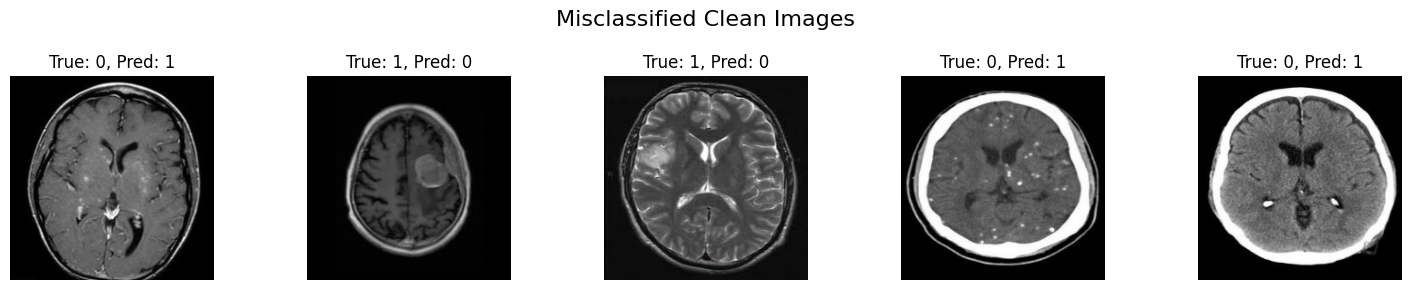

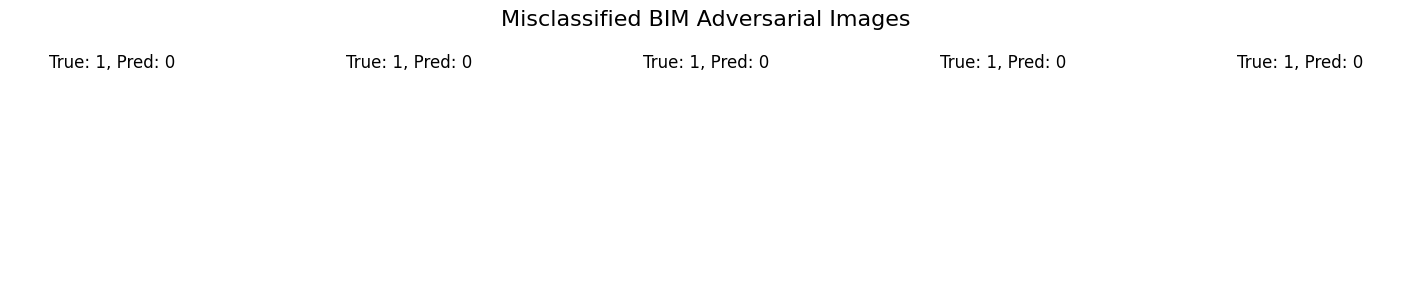

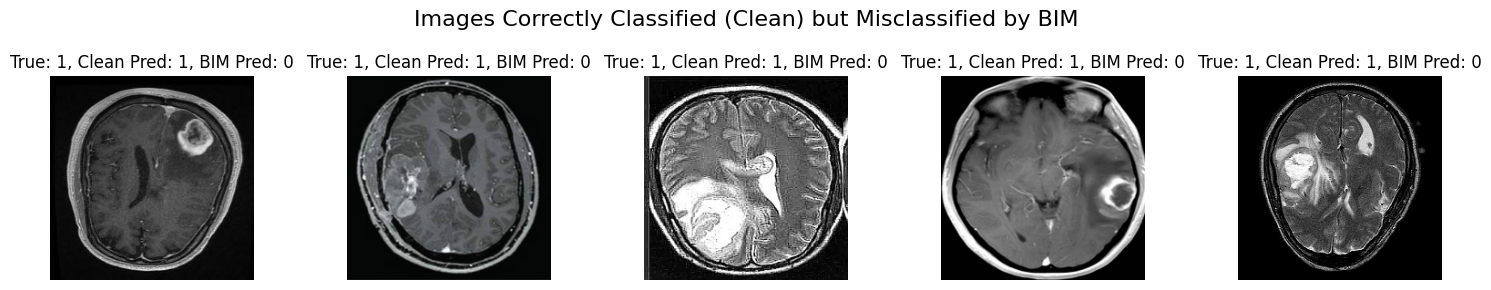

In [ ]:
misclassified_clean_images = []
misclassified_clean_labels = []
misclassified_clean_preds = []

misclassified_bim_images = []
misclassified_bim_labels = []
misclassified_bim_preds = []

correctly_classified_then_bim_misclassified_images = []
correctly_classified_then_bim_misclassified_labels = []
correctly_classified_then_bim_misclassified_clean_preds = []
correctly_classified_then_bim_misclassified_bim_preds = []

num_examples_to_show = 5

# Re-iterate through the validation dataset to get images and make predictions
for images, labels in val_dataset:
    # Make predictions on clean images
    preds_clean_raw = model.predict(images, verbose=0)
    preds_clean = (preds_clean_raw > 0.5).astype(int).flatten()

    # Generate adversarial images
    adv_images = bim_attack(model, images, labels, epsilon, alpha, iterations)

    # Make predictions on BIM adversarial images
    preds_bim_raw = model.predict(adv_images, verbose=0)
    preds_bim = (preds_bim_raw > 0.5).astype(int).flatten()

    labels_np = labels.numpy()

    for i in range(len(labels_np)):
        # Check for misclassified clean images
        if preds_clean[i] != labels_np[i] and len(misclassified_clean_images) < num_examples_to_show:
            misclassified_clean_images.append(images[i].numpy())
            misclassified_clean_labels.append(labels_np[i])
            misclassified_clean_preds.append(preds_clean[i])

        # Check for misclassified BIM adversarial images (regardless of clean prediction)
        if preds_bim[i] != labels_np[i] and len(misclassified_bim_images) < num_examples_to_show:
            misclassified_bim_images.append(adv_images[i].numpy())
            misclassified_bim_labels.append(labels_np[i])
            misclassified_bim_preds.append(preds_bim[i])

        # Check for images correctly classified as clean, but misclassified by BIM
        if preds_clean[i] == labels_np[i] and preds_bim[i] != labels_np[i] and len(correctly_classified_then_bim_misclassified_images) < num_examples_to_show:
            correctly_classified_then_bim_misclassified_images.append(images[i].numpy())
            correctly_classified_then_bim_misclassified_labels.append(labels_np[i])
            correctly_classified_then_bim_misclassified_clean_preds.append(preds_clean[i])
            correctly_classified_then_bim_misclassified_bim_preds.append(preds_bim[i])

    # Stop if we have enough examples for all categories
    if (len(misclassified_clean_images) >= num_examples_to_show and
        len(misclassified_bim_images) >= num_examples_to_show and
        len(correctly_classified_then_bim_misclassified_images) >= num_examples_to_show):
        break


# --- Plotting Misclassified Clean Images ---
if misclassified_clean_images:
    plt.figure(figsize=(15, 3))
    plt.suptitle("Misclassified Clean Images", fontsize=16)
    for i in range(min(len(misclassified_clean_images), num_examples_to_show)):
        plt.subplot(1, num_examples_to_show, i + 1)
        plt.imshow(misclassified_clean_images[i])
        plt.title(f"True: {misclassified_clean_labels[i]}, Pred: {misclassified_clean_preds[i]}")
        plt.axis('off')
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()
else:
    print("No misclassified clean images found (or not enough examples in the first few batches).")

# --- Plotting Misclassified BIM Adversarial Images ---
if misclassified_bim_images:
    plt.figure(figsize=(15, 3))
    plt.suptitle("Misclassified BIM Adversarial Images", fontsize=16)
    for i in range(min(len(misclassified_bim_images), num_examples_to_show)):
        plt.subplot(1, num_examples_to_show, i + 1)
        plt.imshow(misclassified_bim_images[i])
        plt.title(f"True: {misclassified_bim_labels[i]}, Pred: {misclassified_bim_preds[i]}")
        plt.axis('off')
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()
else:
    print("No misclassified BIM adversarial images found (or not enough examples in the first few batches).")

# --- Plotting Images Correctly Classified as Clean but Misclassified by BIM ---
if correctly_classified_then_bim_misclassified_images:
    plt.figure(figsize=(15, 3))
    plt.suptitle("Images Correctly Classified (Clean) but Misclassified by BIM", fontsize=16)
    for i in range(min(len(correctly_classified_then_bim_misclassified_images), num_examples_to_show)):
        plt.subplot(1, num_examples_to_show, i + 1)
        plt.imshow(correctly_classified_then_bim_misclassified_images[i])
        plt.title(f"True: {correctly_classified_then_bim_misclassified_labels[i]}, Clean Pred: {correctly_classified_then_bim_misclassified_clean_preds[i]}, BIM Pred: {correctly_classified_then_bim_misclassified_bim_preds[i]}")
        plt.axis('off')
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()
else:
    print("No images found that were correctly classified as clean but misclassified by BIM (or not enough examples in the first few batches).")


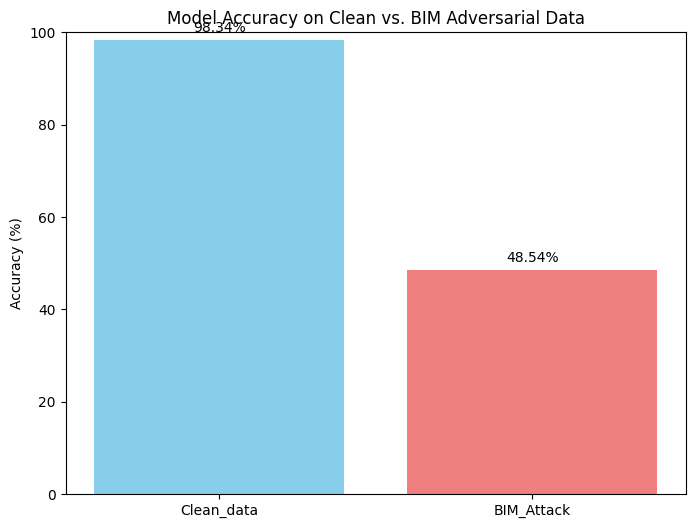

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Data from previous executions
accuracies = {
    'Clean_data': clean_acc,
    'BIM_Attack': np.mean(bim_acc)
}

labels = list(accuracies.keys())
values = [acc * 100 for acc in accuracies.values()]

plt.figure(figsize=(8, 6))
plt.bar(labels, values, color=['skyblue', 'lightcoral'])
plt.ylabel('Accuracy (%)')
plt.title('Model Accuracy on Clean vs. BIM Adversarial Data')
plt.ylim(0, 100) # Ensure y-axis goes from 0 to 100

# Add accuracy values on top of the bars
for i, value in enumerate(values):
    plt.text(i, value + 1, f'{value:.2f}%', ha='center', va='bottom')

plt.show()